# Background and Context
In highly competitive industries such as telecommunications, banking, and subscription-based digital 
services, customer retention is a critical business challenge. Acquiring new customers is significantly 
more expensive than retaining existing ones. Organizations therefore require data-driven mechanisms 
to identify customers who are likely to discontinue their services (churn) so that timely retention 
strategies can be implemented. 
With the availability of historical customer data, machine learning techniques can be leveraged to 
analyze usage patterns and behavioral indicators to predict customer churn in advance.

# Problem Statement
The objective of this project is to develop a machine learning model that predicts whether a customer is 
likely to churn based on their demographic details, service usage patterns, and account-related 
information. The model aims to help organizations proactively identify at-risk customers and take 
preventive actions to improve customer retention and reduce revenue loss.

# Business Objectives
- Reduce customer attrition by identifying high-risk customers early 
- Enable targeted retention campaigns and personalized offers 
- Improve overall customer lifetime value (CLV) 
- Support data-driven decision-making for customer relationship management 

# Machine Learning Objectives
- Build a binary classification model to predict customer churn (Yes/No) 
- Analyze key factors contributing to customer churn 
- Evaluate model performance using appropriate classification metrics

#  Dataset Description 
The dataset used for this project is the Telco Customer Churn Dataset, which is publicly available and widely 
used for machine learning classification tasks.    

Dataset Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn      

The dataset contains historical customer records with the following types of features:
- Customer Demographics: Gender, senior citizen status, partner, dependents 
- Account Information: Tenure, contract type, payment method, billing details 
- Service Usage: Internet service, phone service, streaming services 
- Target Variable: Churn (Yes/No)

Each row represents a unique customer, and the dataset includes both numerical and categorical 
variables. 

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [3]:
df = pd.read_csv("Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis (EDA)

In this section we explore the dataset to understand:
- data types
- missing values
- class distribution

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There is a critical observation here. In the column 'TotalCharges', we see 'object' datatype but this column is primarily float type. ALso, the null count is zero for the same. Possible reasons may be some entries as blank spaces or some string data stored there.

In [6]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Above are the rows where TotalCharges has non numeric (blank space) values. We will convert them to NaN

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Now we clearly see there are 11 missing values in the TotalCharges column. Let's drop those rows with missing values.

In [9]:
df=df.dropna()

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now we have handled all null values. But some columns need re-adjustment in their values.

Converting 'No internet service' to 'No'.

In [11]:
cols = [
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies'
]

for col in cols:
    df[col] = df[col].replace('No internet service', 'No')

Converting 'No phone service' to 'No'.

In [12]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

Also drop customerID column because neither does it provide any insight nor help with ML models. 

In [13]:
df = df.drop('customerID', axis = 1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Now let's take a glance of statistical data.

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## EDA - Visualization

In this section, we explore the dataset to understand the relationship between different features and customer churn. The goal is to identify patterns and potential drivers of churn that may help improve our machine learning model.

### Plots used:

1. Churn Distribution
2. Contract Type vs Churn
3. Tenure vs Churn
4. Monthly Charges vs Churn
5. Internet Service vs Churn
6. Payment Method vs Churn
7. Correlation Heatmap

#### 1. Churn Distribution

<Axes: xlabel='Churn', ylabel='count'>

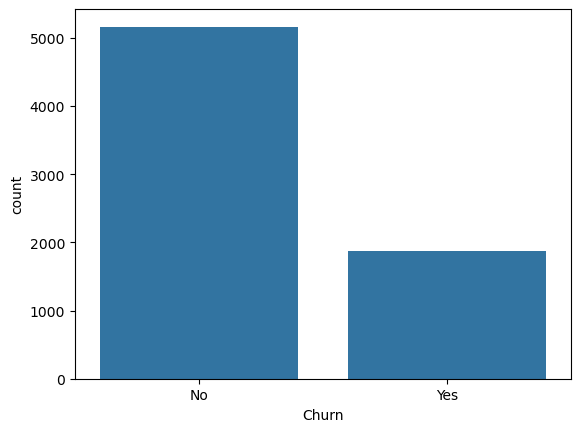

In [15]:
sns.countplot(x='Churn', data=df)

#### 2. Contract Type vs Customer Churn

<Axes: xlabel='Contract', ylabel='count'>

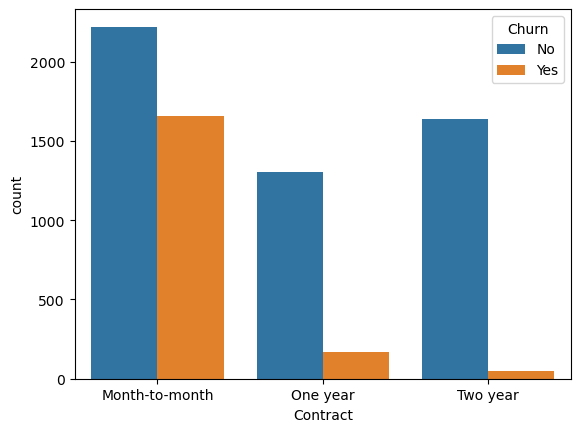

In [16]:
sns.countplot(x='Contract', hue='Churn', data=df)

#### 3. Tenure vs Churn

<Axes: xlabel='Churn', ylabel='tenure'>

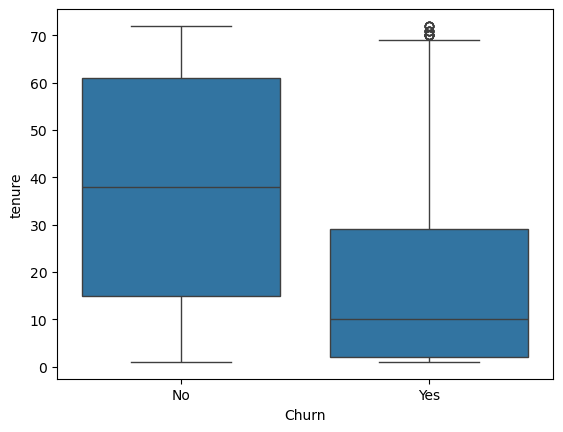

In [17]:
sns.boxplot(x='Churn', y='tenure', data=df)

#### 4. Monthly Charges vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

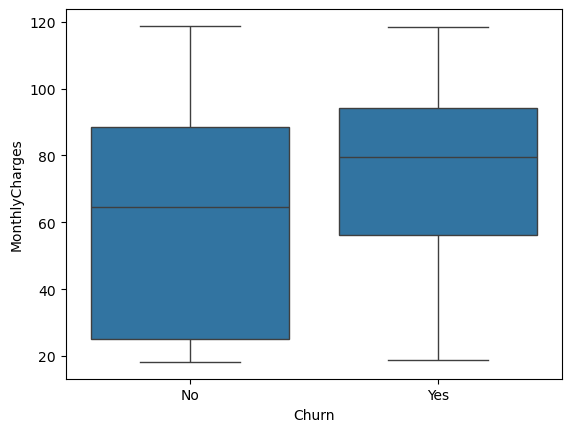

In [18]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

#### 5. Internet Service vs Churn

<Axes: xlabel='InternetService', ylabel='count'>

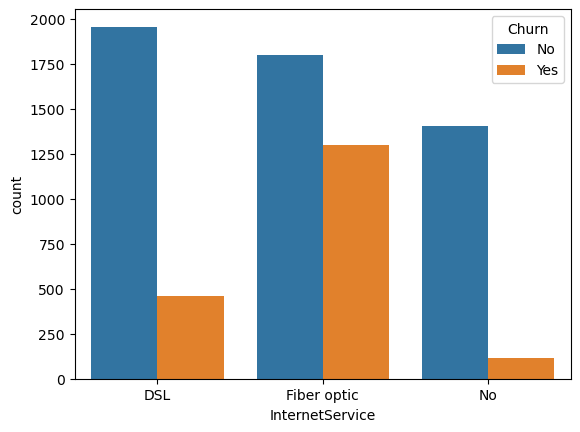

In [19]:
sns.countplot(x='InternetService', hue='Churn', data=df)

#### 6. Payment Method vs Churn

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

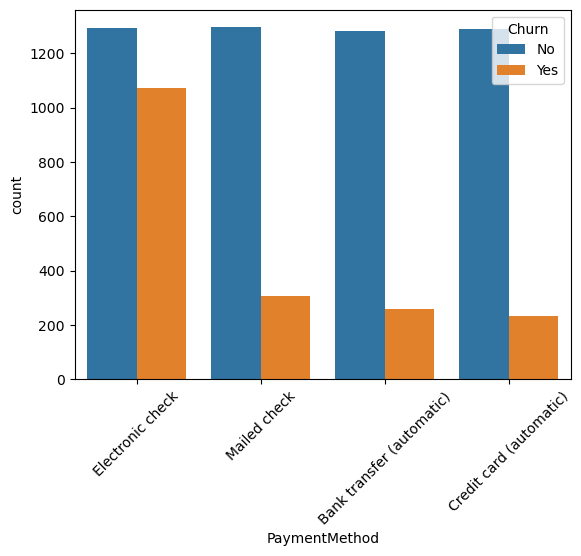

In [20]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)

#### 7.Correlation Heatmap

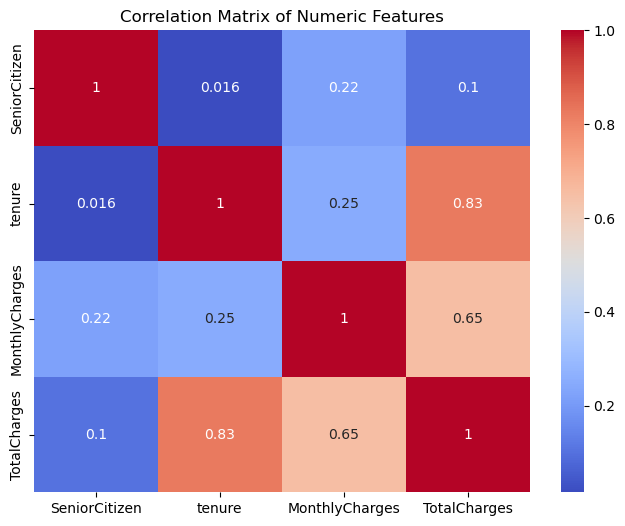

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

### Key Insights from EDA - Visualization

1. Customers with month-to-month contracts exhibit the highest churn.
2. Customers with lower tenure are more likely to churn.
3. Higher monthly charges correlate with increased churn risk.
4. Fiber optic users show higher churn compared to DSL users.
5. Electronic check payment method is associated with higher churn.

These insights suggest that pricing structure, contract commitment, and service type significantly influence churn behavior.

# Machine Learning

In this section, we build machine learning models to predict customer churn.  
The workflow includes preprocessing using pipelines, hyperparameter tuning using GridSearchCV, and model comparison based on ROC-AUC and classification metrics.

## Train-Test Split

In [22]:
X = df.drop('Churn', axis = 1)
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
y = df['Churn']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 54)

## Defining Column Types

In [24]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include='object').columns

## Preprocessing Transformer

In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

## Importing Models

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Creating Model Dictionary

In [27]:
models = {
    "Logistic Regression" : {
        'model' : LogisticRegression(max_iter=1000),
        'params' : {
            "model__C" : [0.01, 0.1, 1, 10]
        }
    },
    "Decision Tree" : {
        'model' : DecisionTreeClassifier(),
        'params' : {
            "model__max_depth" : [3,5,7,10],
            "model__min_samples_split" : [2,5,10]
        }
    },
    "Random Forest" : {
        'model' : RandomForestClassifier(),
        'params' : {
            "model__n_estimators" : [100,200],
            "model__max_depth" : [None, 10, 20]
        }
    }
}

***Note*** :
The class_weight parameter of LogisticRegression() was tested but ultimately removed, as it slightly reduced ROC-AUC performance. Instead, class imbalance was handled through ROC-based threshold optimization, which allows the model to adjust decision boundaries without altering probability calibration.

## Importing pipeline and GridSearch CV

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

## Define Cross Validation

In [29]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 54)

## Import all Metrics

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Loop Through Models

In [31]:
results = []
best_models = {}

for model, config in models.items():

    pipeline = Pipeline([
        ('Preprocessing', preprocessor),
        ('model', config['model'])
    ])

    grid = GridSearchCV(
        pipeline,
        config['params'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # store the trained model
    best_models[model] = best_model

    y_prob = best_model.predict_proba(X_test)[:,1]

    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    optimal_idx = (tpr - fpr).argmax()
    optimal_threshold = thresholds[optimal_idx]

    y_pred = (y_prob >= optimal_threshold).astype(int)

    results.append({
        'Model': model,
        'Optimal_Threshold': optimal_threshold,
        'Accuracy_Score': accuracy_score(y_test, y_pred),
        'Precision_Score': precision_score(y_test, y_pred),
        'Recall_Score': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'ROC_AUC_Score': roc_auc_score(y_test, y_prob)
    })



results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC_AUC_Score', ascending=False)

best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]

## Model Comparison

In [32]:
results_df = results_df.sort_values('ROC_AUC_Score', ascending=False)
results_df = results_df.round(3)
results_df

,Model,Optimal_Threshold,Accuracy_Score,Precision_Score,Recall_Score,F1_Score,ROC_AUC_Score
0,Logistic Regression,0.310,0.778,0.566,0.764,0.650,0.848
2,Random Forest,0.299,0.776,0.563,0.774,0.652,0.843
1,Decision Tree,0.252,0.737,0.509,0.780,0.616,0.827


## Threshold Optimization for Churn Prediction

In classification models, predictions are typically converted from probabilities to class labels using a default threshold of 0.5. However, in churn prediction problems this threshold may not be optimal.     
Instead of using a fixed threshold, the optimal threshold was determined using the ROC curve. Specifically, the threshold that maximizes Youden's J statistic was selected:     

J=TPR−FPR

Where:

TPR (True Positive Rate) represents the proportion of churners correctly identified.

FPR (False Positive Rate) represents the proportion of non-churners incorrectly flagged.

Maximizing TPR−FPR identifies the point where the model best separates churners from non-churners.

In practical business applications, this threshold may be further adjusted depending on the cost of customer churn versus the cost of retention incentives.

## ROC Curve

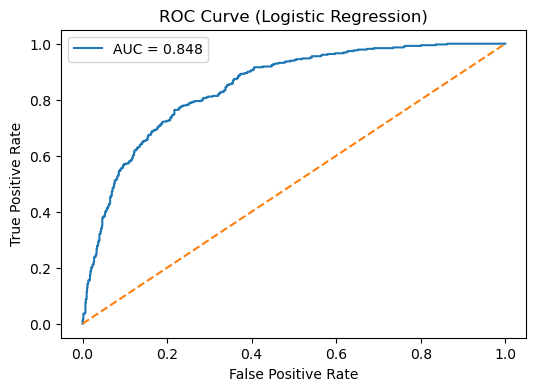

In [33]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({best_model_name})")
plt.legend()
plt.show()

# Feature Importance Analysis

In [34]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=54,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
4,tenure,0.118763
7,InternetService,0.095522
17,MonthlyCharges,0.060697
14,Contract,0.029495
18,TotalCharges,0.023952
13,StreamingMovies,0.012580
6,MultipleLines,0.008813
12,StreamingTV,0.007534
16,PaymentMethod,0.006752
15,PaperlessBilling,0.005330


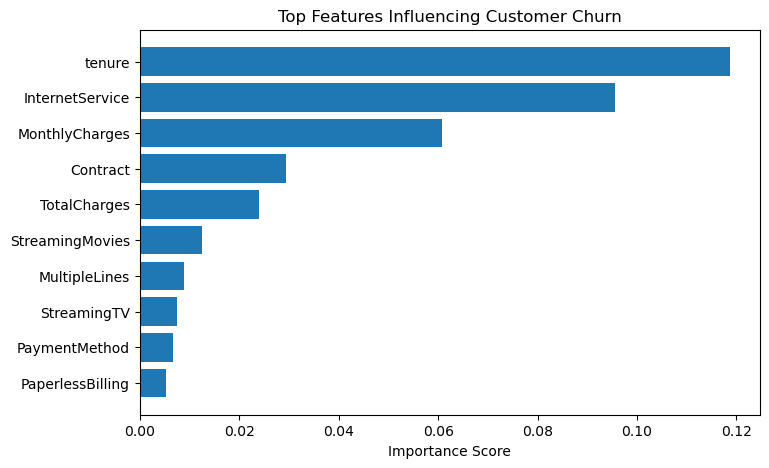

In [35]:
top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Importance Score")
plt.show()

# Actionable Insights for Business Stakeholders

Based on the model analysis and feature importance results, several key factors influencing customer churn were identified. These insights can guide targeted retention strategies.

## 1. Focus on Customers with Low Tenure
Customers with **short tenure** show a significantly higher probability of churn. This indicates that the initial months of the customer lifecycle are critical.

**Recommended actions:**
- Provide onboarding support and tutorials.
- Offer early loyalty incentives for customers within the first 6–12 months.
- Create welcome discounts or bundled service offers.

---

## 2. Address Risks in Month-to-Month Contracts
Customers on **month-to-month contracts** are more likely to churn compared to those with longer-term agreements.

**Recommended actions:**
- Offer discounts for switching to **annual or multi-year contracts**.
- Provide loyalty rewards for long-term commitments.
- Introduce flexible upgrade plans to reduce switching behavior.

---

## 3. Monitor Customers with High Monthly Charges
Customers paying **higher monthly charges** may be more sensitive to price and therefore more likely to churn.

**Recommended actions:**
- Offer personalized pricing plans or bundled services.
- Provide targeted promotions to high-paying customers.
- Highlight value-added services to justify pricing.

---

## 4. Promote Value-Added Services
Services such as **Online Security, Tech Support, and Device Protection** often correlate with lower churn.

**Recommended actions:**
- Bundle these services with standard plans.
- Provide limited-time free trials to encourage adoption.
- Highlight these services during customer onboarding.

---

## 5. Implement Proactive Retention Campaigns
The churn prediction model can identify **high-risk customers in advance**, enabling proactive retention strategies.

**Recommended actions:**
- Trigger retention offers when predicted churn probability exceeds the optimized threshold.
- Use personalized communication and targeted promotions.
- Assign customer success teams to high-risk accounts.

---

# Strategic Impact
By combining predictive modeling with targeted interventions, telecom companies can:

- Reduce customer churn  
- Increase customer lifetime value  
- Optimize marketing and retention spending  

These insights enable a **data-driven approach to customer retention**, improving both profitability and customer satisfaction.

# Conclusion

This project developed a machine learning framework to predict customer churn in a telecom dataset. After performing data preprocessing, exploratory data analysis, and feature engineering, multiple models were trained and evaluated using cross-validation and ROC-AUC scoring.

Among the models tested, **Logistic Regression achieved the highest ROC-AUC score**, indicating strong ability to distinguish between customers who churn and those who remain.

To improve classification performance, the default probability threshold of **0.5 was replaced with an optimized threshold derived from the ROC curve**, improving the balance between recall and false positive rates.

Feature importance analysis highlighted **tenure, contract type, and monthly charges** as key drivers of churn, providing actionable insights for business stakeholders.

Overall, this project demonstrates a complete end-to-end machine learning workflow — from data exploration to predictive modeling and business interpretation — enabling telecom companies to proactively identify high-risk customers and implement targeted retention strategies.

## Deployment

In [36]:
# retrain on full dataset
best_model.fit(X, y)

import joblib
joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']